# 04 — Siamese CNN per FCGR di eccDNA

## Obiettivo

Questo notebook implementa il primo modello Siamese della pipeline.

Ogni ramo della rete riceve una FCGR normalizzata e utilizza lo stesso
CNN encoder per trasformarla in un embedding.

La pipeline è:

DNA / eccDNA
→ FCGR
→ CNN encoder condiviso
→ embedding
→ distanza euclidea
→ Contrastive Loss

Le coppie positive appartengono alla stessa classe patologica, mentre le
coppie negative appartengono a classi differenti.

In questa prima baseline vengono utilizzati:

- FCGR con `k = 6` (`64 × 64`);
- embedding dimension = `128`;
- distanza euclidea;
- Contrastive Loss;
- target `1` per coppie positive;
- target `0` per coppie negative.

La classificazione multiclass tramite prototipi degli embedding verrà
affrontata successivamente.

In [1]:
from pathlib import Path

import json
import random
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)


print(
    "PyTorch:",
    torch.__version__
)

print(
    "CUDA disponibile:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

PyTorch: 2.12.0+cu126
CUDA disponibile: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
CURRENT_DIR = (
    Path.cwd()
    .resolve()
)


if CURRENT_DIR.name == "notebooks":

    PROJECT_ROOT = (
        CURRENT_DIR.parent
    )

else:

    PROJECT_ROOT = (
        CURRENT_DIR
    )


PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)


ARTIFACTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "siamese_baseline"
)


ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PAIR_CONFIG_PATH = (
    PROCESSED_DIR
    / "siamese_pair_config.json"
)


MANIFEST_PATH = (
    PROCESSED_DIR
    / "siamese_primary_manifest.tsv"
)


VAL_POOL_PATH = (
    PROCESSED_DIR
    / "siamese_val_pair_pool.tsv"
)


TEST_POOL_PATH = (
    PROCESSED_DIR
    / "siamese_test_pair_pool.tsv"
)


with open(
    PAIR_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:

    PAIR_CONFIG = json.load(f)


DEFAULT_K = int(
    PAIR_CONFIG["k"]
)


BATCH_SIZE = int(
    PAIR_CONFIG["batch_size"]
)


TRAIN_PAIRS_PER_EPOCH = int(
    PAIR_CONFIG[
        "train_pairs_per_epoch"
    ]
)


VAL_PAIRS = int(
    PAIR_CONFIG["val_pairs"]
)


TEST_PAIRS = int(
    PAIR_CONFIG["test_pairs"]
)


POSITIVE_PAIR_PROBABILITY = float(
    PAIR_CONFIG[
        "positive_probability"
    ]
)


RANDOM_STATE = int(
    PAIR_CONFIG["random_state"]
)


FCGR_MEMMAP_PATH = (
    PROCESSED_DIR
    / "fcgr_cache"
    / f"fcgr_k{DEFAULT_K}.npy"
)


FCGR_INDEX_PATH = (
    PROCESSED_DIR
    / "fcgr_cache"
    / f"fcgr_k{DEFAULT_K}_index.tsv"
)


print(
    "Project root:",
    PROJECT_ROOT
)

print(
    "k:",
    DEFAULT_K
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Train pairs / epoch:",
    TRAIN_PAIRS_PER_EPOCH
)

print(
    "FCGR:",
    FCGR_MEMMAP_PATH
)

Project root: D:\Daria\Desktop\eccdna_fcgr_siamese
k: 6
Batch size: 64
Train pairs / epoch: 50000
FCGR: D:\Daria\Desktop\eccdna_fcgr_siamese\data\processed\fcgr_cache\fcgr_k6.npy


In [3]:
def set_seed(
    seed
):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )


set_seed(
    RANDOM_STATE
)


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Device:",
    DEVICE
)

Device: cuda


In [4]:
metadata = pd.read_csv(
    MANIFEST_PATH,
    sep="\t",
    dtype={
        "id": str
    }
)


val_pair_pool = pd.read_csv(
    VAL_POOL_PATH,
    sep="\t",
    dtype={
        "id": str
    }
)


test_pair_pool = pd.read_csv(
    TEST_POOL_PATH,
    sep="\t",
    dtype={
        "id": str
    }
)


train_metadata = (
    metadata[
        metadata[
            "split_cluster"
        ] == "train"
    ]
    .copy()
)


for dataframe in [
    train_metadata,
    val_pair_pool,
    test_pair_pool
]:

    dataframe[
        "class_id"
    ] = (
        dataframe[
            "class_id"
        ]
        .astype(int)
    )


print(
    "Train samples:",
    f"{len(train_metadata):,}"
)

print(
    "Validation pool:",
    f"{len(val_pair_pool):,}"
)

print(
    "Test pool:",
    f"{len(test_pair_pool):,}"
)

print(
    "Classi:",
    train_metadata[
        "class_id"
    ].nunique()
)

Train samples: 126,265
Validation pool: 12,937
Test pool: 11,070
Classi: 18


In [5]:
fcgr_memmap = np.load(
    FCGR_MEMMAP_PATH,
    mmap_mode="r"
)


fcgr_index = pd.read_csv(
    FCGR_INDEX_PATH,
    sep="\t",
    dtype={
        "id": str
    }
)


id_to_fcgr_row = dict(
    zip(
        fcgr_index[
            "id"
        ],

        fcgr_index[
            "fcgr_row"
        ]
    )
)


print(
    "FCGR shape:",
    fcgr_memmap.shape
)

print(
    "FCGR dtype:",
    fcgr_memmap.dtype
)

print(
    "Indice:",
    len(
        id_to_fcgr_row
    )
)


assert (
    fcgr_memmap.dtype
    == np.float32
)


assert (
    len(
        id_to_fcgr_row
    )
    ==
    fcgr_memmap.shape[0]
)

FCGR shape: (150272, 64, 64)
FCGR dtype: float32
Indice: 150272


In [6]:
class SiamesePairDataset(
    Dataset
):

    def __init__(
        self,
        metadata,
        fcgr_memmap,
        id_to_row,
        pairs_per_epoch,
        positive_probability=0.5,
        seed=42,
        deterministic=False
    ):

        self.metadata = (
            metadata
            .copy()
            .reset_index(drop=True)
        )


        self.fcgr_memmap = (
            fcgr_memmap
        )


        self.id_to_row = (
            id_to_row
        )


        self.pairs_per_epoch = int(
            pairs_per_epoch
        )


        self.positive_probability = float(
            positive_probability
        )


        self.seed = int(
            seed
        )


        self.deterministic = (
            deterministic
        )


        self.rng = (
            np.random.default_rng(
                self.seed
            )
        )


        self.class_to_ids = {

            int(class_id):
            group["id"]
            .astype(str)
            .tolist()

            for class_id, group
            in self.metadata.groupby(
                "class_id"
            )
        }


        self.classes = np.array(
            sorted(
                self.class_to_ids.keys()
            ),
            dtype=np.int64
        )


        for class_id in self.classes:

            if (
                len(
                    self.class_to_ids[
                        int(class_id)
                    ]
                )
                < 2
            ):

                raise ValueError(
                    f"Classe {class_id} "
                    "con meno di 2 sample."
                )


    def __len__(
        self
    ):

        return (
            self.pairs_per_epoch
        )


    def _get_rng(
        self,
        index
    ):

        if self.deterministic:

            return (
                np.random.default_rng(
                    self.seed
                    + int(index)
                )
            )

        return (
            self.rng
        )


    def _sample_pair(
        self,
        rng
    ):

        # ----------------------------------
        # Classe anchor
        # ----------------------------------

        class1 = int(
            rng.choice(
                self.classes
            )
        )


        ids_class1 = (
            self.class_to_ids[
                class1
            ]
        )


        id1 = str(
            rng.choice(
                ids_class1
            )
        )


        # ----------------------------------
        # Positive pair
        # ----------------------------------

        if (
            rng.random()
            <
            self.positive_probability
        ):

            class2 = (
                class1
            )


            id2 = (
                id1
            )


            while (
                id2
                ==
                id1
            ):

                id2 = str(
                    rng.choice(
                        ids_class1
                    )
                )


            target = (
                1.0
            )


        # ----------------------------------
        # Negative pair
        # ----------------------------------

        else:

            possible_classes = (
                self.classes[
                    self.classes
                    != class1
                ]
            )


            class2 = int(
                rng.choice(
                    possible_classes
                )
            )


            id2 = str(
                rng.choice(
                    self.class_to_ids[
                        class2
                    ]
                )
            )


            target = (
                0.0
            )


        return (
            id1,
            id2,
            class1,
            class2,
            target
        )


    def _load_fcgr(
        self,
        sample_id
    ):

        row = (
            self.id_to_row[
                str(sample_id)
            ]
        )


        fcgr = np.array(
            self.fcgr_memmap[
                row
            ],
            dtype=np.float32,
            copy=True
        )


        tensor = (
            torch.from_numpy(
                fcgr
            )
            .unsqueeze(0)
        )


        return tensor


    def __getitem__(
        self,
        index
    ):

        rng = (
            self._get_rng(
                index
            )
        )


        (
            id1,
            id2,
            class1,
            class2,
            target
        ) = (
            self._sample_pair(
                rng
            )
        )


        x1 = (
            self._load_fcgr(
                id1
            )
        )


        x2 = (
            self._load_fcgr(
                id2
            )
        )


        return {

            "x1":
                x1,

            "x2":
                x2,

            "target":
                torch.tensor(
                    target,
                    dtype=torch.float32
                ),

            "id1":
                id1,

            "id2":
                id2,

            "class1":
                class1,

            "class2":
                class2
        }

In [7]:
train_dataset = SiamesePairDataset(

    metadata=
        train_metadata,

    fcgr_memmap=
        fcgr_memmap,

    id_to_row=
        id_to_fcgr_row,

    pairs_per_epoch=
        TRAIN_PAIRS_PER_EPOCH,

    positive_probability=
        POSITIVE_PAIR_PROBABILITY,

    seed=
        RANDOM_STATE,

    deterministic=False
)


val_dataset = SiamesePairDataset(

    metadata=
        val_pair_pool,

    fcgr_memmap=
        fcgr_memmap,

    id_to_row=
        id_to_fcgr_row,

    pairs_per_epoch=
        VAL_PAIRS,

    positive_probability=
        POSITIVE_PAIR_PROBABILITY,

    seed=
        RANDOM_STATE + 10_000,

    deterministic=True
)


test_dataset = SiamesePairDataset(

    metadata=
        test_pair_pool,

    fcgr_memmap=
        fcgr_memmap,

    id_to_row=
        id_to_fcgr_row,

    pairs_per_epoch=
        TEST_PAIRS,

    positive_probability=
        POSITIVE_PAIR_PROBABILITY,

    seed=
        RANDOM_STATE + 20_000,

    deterministic=True
)


NUM_WORKERS = 0


train_loader = DataLoader(

    train_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=
        torch.cuda.is_available()
)


val_loader = DataLoader(

    val_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=
        torch.cuda.is_available()
)


test_loader = DataLoader(

    test_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=
        torch.cuda.is_available()
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 782
Validation batches: 157
Test batches: 157


In [9]:
batch = next(
    iter(
        train_loader
    )
)


print(
    "x1:",
    batch["x1"].shape,
    batch["x1"].dtype
)

print(
    "x2:",
    batch["x2"].shape,
    batch["x2"].dtype
)

print(
    "target:",
    batch["target"].shape,
    batch["target"].dtype
)


print()

print(
    "Positive:",
    (
        batch[
            "target"
        ] == 1
    ).sum().item()
)

print(
    "Negative:",
    (
        batch[
            "target"
        ] == 0
    ).sum().item()
)


assert (
    batch["x1"].shape[1:]
    ==
    (
        1,
        64,
        64
    )
)


assert (
    batch["x1"].dtype
    ==
    torch.float32
)

x1: torch.Size([64, 1, 64, 64]) torch.float32
x2: torch.Size([64, 1, 64, 64]) torch.float32
target: torch.Size([64]) torch.float32

Positive: 35
Negative: 29


# CNN Encoder

La rete Siamese utilizza un unico CNN encoder condiviso tra i due rami.

Questo significa che entrambe le FCGR vengono processate dagli stessi
parametri θ:

`z1 = Encoder(x1)`

`z2 = Encoder(x2)`

L'encoder produce un embedding di 128 dimensioni.

Gli embedding vengono normalizzati tramite norma L2. In questo modo
la loro scala rimane controllata e la distanza euclidea dipende
principalmente dalla posizione relativa dei sample nello spazio degli
embedding.

In [10]:
class FCGRCNNEncoder(
    nn.Module
):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()


        self.features = nn.Sequential(

            # --------------------------------
            # 64 x 64
            # --------------------------------

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                32
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.Conv2d(
                32,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.MaxPool2d(
                kernel_size=2
            ),


            # --------------------------------
            # 32 x 32
            # --------------------------------

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                64
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.MaxPool2d(
                kernel_size=2
            ),


            # --------------------------------
            # 16 x 16
            # --------------------------------

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                128
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.MaxPool2d(
                kernel_size=2
            ),


            # --------------------------------
            # 8 x 8
            # --------------------------------

            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(
                128
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.AdaptiveAvgPool2d(
                (
                    4,
                    4
                )
            )
        )


        self.projection = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 4 * 4,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                p=0.20
            ),

            nn.Linear(
                256,
                embedding_dim
            )
        )


    def forward(
        self,
        x
    ):

        x = (
            self.features(
                x
            )
        )


        z = (
            self.projection(
                x
            )
        )


        z = F.normalize(
            z,
            p=2,
            dim=1
        )


        return z

In [11]:
class SiameseNetwork(
    nn.Module
):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()


        self.encoder = (
            FCGRCNNEncoder(
                embedding_dim=
                    embedding_dim
            )
        )


    def forward(
        self,
        x1,
        x2
    ):

        z1 = (
            self.encoder(
                x1
            )
        )


        z2 = (
            self.encoder(
                x2
            )
        )


        return (
            z1,
            z2
        )

In [12]:
class ContrastiveLoss(
    nn.Module
):

    def __init__(
        self,
        margin=1.0
    ):

        super().__init__()

        self.margin = float(
            margin
        )


    def forward(
        self,
        z1,
        z2,
        target
    ):

        distance = (
            F.pairwise_distance(
                z1,
                z2,
                p=2
            )
        )


        positive_loss = (
            target
            *
            distance.pow(2)
        )


        negative_loss = (

            (1.0 - target)

            *

            F.relu(
                self.margin
                -
                distance
            ).pow(2)
        )


        loss = (
            positive_loss
            +
            negative_loss
        )


        return (
            loss.mean(),
            distance
        )

In [13]:
EMBEDDING_DIM = 128

MARGIN = 1.0


model = SiameseNetwork(
    embedding_dim=
        EMBEDDING_DIM
)


model = model.to(
    DEVICE
)


criterion = ContrastiveLoss(
    margin=
        MARGIN
)


n_parameters = sum(
    parameter.numel()
    for parameter
    in model.parameters()
)


n_trainable_parameters = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)


print(
    model
)


print()

print(
    "Parametri totali:",
    f"{n_parameters:,}"
)

print(
    "Parametri trainabili:",
    f"{n_trainable_parameters:,}"
)

SiameseNetwork(
  (encoder): FCGRCNNEncoder(
    (features): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (12): ReLU(inplace=True)
      (13): MaxPo

In [14]:
model.eval()


x1 = (
    batch["x1"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


x2 = (
    batch["x2"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


targets = (
    batch["target"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


with torch.no_grad():

    z1, z2 = model(
        x1,
        x2
    )


    loss, distances = criterion(
        z1,
        z2,
        targets
    )


print(
    "x1:",
    x1.shape
)

print(
    "z1:",
    z1.shape
)

print(
    "z2:",
    z2.shape
)

print(
    "Loss:",
    loss.item()
)

print(
    "Distance min:",
    distances.min().item()
)

print(
    "Distance max:",
    distances.max().item()
)

print(
    "Distance mean:",
    distances.mean().item()
)

x1: torch.Size([64, 1, 64, 64])
z1: torch.Size([64, 128])
z2: torch.Size([64, 128])
Loss: 0.4530729055404663
Distance min: 1.3670192856807262e-05
Distance max: 0.0003553630376700312
Distance mean: 4.8553698434261605e-05


In [15]:
embedding_norms = torch.linalg.vector_norm(
    z1,
    dim=1
)


print(
    "Norma minima:",
    embedding_norms.min().item()
)

print(
    "Norma massima:",
    embedding_norms.max().item()
)

print(
    "Norma media:",
    embedding_norms.mean().item()
)

Norma minima: 0.9999999403953552
Norma massima: 1.0
Norma media: 1.0


# Training

Il modello viene ottimizzato mediante AdamW.

Il training utilizza coppie generate dinamicamente ad ogni epoca,
mentre validation e test utilizzano coppie deterministiche.

Il checkpoint viene selezionato sulla `validation contrastive loss`.

Il test set non viene utilizzato durante il training né per la scelta
dell'epoca migliore.

In [16]:
EPOCHS = 20

LEARNING_RATE = 1e-3

WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 5

MIN_DELTA = 1e-4


CHECKPOINT_PATH = (
    ARTIFACTS_DIR
    / "best_siamese_euclidean_contrastive.pt"
)


HISTORY_PATH = (
    ARTIFACTS_DIR
    / "training_history.csv"
)


print(
    "Epoch:",
    EPOCHS
)

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "Patience:",
    EARLY_STOPPING_PATIENCE
)

print(
    "Checkpoint:",
    CHECKPOINT_PATH
)

Epoch: 20
Learning rate: 0.001
Patience: 5
Checkpoint: D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\siamese_baseline\best_siamese_euclidean_contrastive.pt


In [17]:
def run_epoch(
    model,
    loader,
    criterion,
    device,
    optimizer=None,
    scaler=None
):

    training = (
        optimizer
        is not None
    )


    if training:

        model.train()

    else:

        model.eval()


    total_loss = 0.0

    total_samples = 0


    all_distances = []

    all_targets = []


    for batch in loader:

        x1 = (
            batch["x1"]
            .to(
                device,
                non_blocking=True
            )
        )


        x2 = (
            batch["x2"]
            .to(
                device,
                non_blocking=True
            )
        )


        targets = (
            batch["target"]
            .to(
                device,
                non_blocking=True
            )
        )


        if training:

            optimizer.zero_grad(
                set_to_none=True
            )


        with torch.set_grad_enabled(
            training
        ):

            with torch.autocast(

                device_type=
                    device.type,

                dtype=
                    torch.float16,

                enabled=
                    (
                        device.type
                        ==
                        "cuda"
                    )
            ):

                z1, z2 = model(
                    x1,
                    x2
                )


                loss, distances = (
                    criterion(
                        z1,
                        z2,
                        targets
                    )
                )


        if training:

            scaler.scale(
                loss
            ).backward()


            scaler.step(
                optimizer
            )


            scaler.update()


        batch_size = (
            targets.shape[0]
        )


        total_loss += (
            loss.item()
            *
            batch_size
        )


        total_samples += (
            batch_size
        )


        all_distances.append(

            distances
            .detach()
            .cpu()
            .numpy()
        )


        all_targets.append(

            targets
            .detach()
            .cpu()
            .numpy()
        )


    all_distances = (
        np.concatenate(
            all_distances
        )
    )


    all_targets = (
        np.concatenate(
            all_targets
        )
        .astype(int)
    )


    average_loss = (
        total_loss
        /
        total_samples
    )


    positive_distances = (
        all_distances[
            all_targets == 1
        ]
    )


    negative_distances = (
        all_distances[
            all_targets == 0
        ]
    )


    return {

        "loss":
            average_loss,

        "mean_positive_distance":
            positive_distances.mean(),

        "mean_negative_distance":
            negative_distances.mean(),

        "distances":
            all_distances,

        "targets":
            all_targets
    }

In [18]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=
        LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY
)


scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=0.5,

        patience=2
    )
)


USE_AMP = (
    DEVICE.type
    ==
    "cuda"
)


scaler = torch.amp.GradScaler(

    "cuda",

    enabled=
        USE_AMP
)


print(
    "Mixed precision:",
    USE_AMP
)

Mixed precision: True


In [19]:
history = []


best_val_loss = (
    float("inf")
)


epochs_without_improvement = (
    0
)


training_start = (
    time.perf_counter()
)


for epoch in range(
    1,
    EPOCHS + 1
):

    epoch_start = (
        time.perf_counter()
    )


    # ==============================
    # TRAIN
    # ==============================

    train_results = run_epoch(

        model=
            model,

        loader=
            train_loader,

        criterion=
            criterion,

        device=
            DEVICE,

        optimizer=
            optimizer,

        scaler=
            scaler
    )


    # ==============================
    # VALIDATION
    # ==============================

    val_results = run_epoch(

        model=
            model,

        loader=
            val_loader,

        criterion=
            criterion,

        device=
            DEVICE
    )


    val_loss = (
        val_results[
            "loss"
        ]
    )


    scheduler.step(
        val_loss
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    epoch_time = (
        time.perf_counter()
        -
        epoch_start
    )


    history.append({

        "epoch":
            epoch,

        "train_loss":
            train_results[
                "loss"
            ],

        "val_loss":
            val_loss,

        "train_positive_distance":
            train_results[
                "mean_positive_distance"
            ],

        "train_negative_distance":
            train_results[
                "mean_negative_distance"
            ],

        "val_positive_distance":
            val_results[
                "mean_positive_distance"
            ],

        "val_negative_distance":
            val_results[
                "mean_negative_distance"
            ],

        "learning_rate":
            current_lr,

        "epoch_seconds":
            epoch_time
    })


    print(
        f"Epoch {epoch:02d}/{EPOCHS}"
        f" | train_loss="
        f"{train_results['loss']:.5f}"
        f" | val_loss="
        f"{val_loss:.5f}"
        f" | val d+="
        f"{val_results['mean_positive_distance']:.4f}"
        f" | val d-="
        f"{val_results['mean_negative_distance']:.4f}"
        f" | lr="
        f"{current_lr:.2e}"
        f" | {epoch_time:.1f}s"
    )


    # ==============================
    # CHECKPOINT
    # ==============================

    if (
        val_loss
        <
        best_val_loss
        -
        MIN_DELTA
    ):

        best_val_loss = (
            val_loss
        )


        epochs_without_improvement = (
            0
        )


        torch.save(

            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_loss":
                    val_loss,

                "embedding_dim":
                    EMBEDDING_DIM,

                "margin":
                    MARGIN,

                "k":
                    DEFAULT_K
            },

            CHECKPOINT_PATH
        )


        print(
            "  → nuovo best checkpoint"
        )


    else:

        epochs_without_improvement += (
            1
        )


        print(
            "  → no improvement:",
            epochs_without_improvement,
            "/",
            EARLY_STOPPING_PATIENCE
        )


    # ==============================
    # EARLY STOPPING
    # ==============================

    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print()
        print(
            "Early stopping."
        )

        break


training_seconds = (
    time.perf_counter()
    -
    training_start
)


print()

print(
    "Training terminato."
)

print(
    "Tempo totale:",
    f"{training_seconds / 60:.2f} min"
)

print(
    "Best val loss:",
    best_val_loss
)

Epoch 01/20 | train_loss=0.24058 | val_loss=0.39672 | val d+=0.0936 | val d-=0.1209 | lr=1.00e-03 | 213.0s
  → nuovo best checkpoint
Epoch 02/20 | train_loss=0.23590 | val_loss=0.35690 | val d+=0.1487 | val d-=0.1820 | lr=1.00e-03 | 189.1s
  → nuovo best checkpoint
Epoch 03/20 | train_loss=0.23532 | val_loss=0.27677 | val d+=0.2639 | val d-=0.3372 | lr=1.00e-03 | 188.6s
  → nuovo best checkpoint
Epoch 04/20 | train_loss=0.23325 | val_loss=0.34231 | val d+=0.1640 | val d-=0.2023 | lr=1.00e-03 | 178.3s
  → no improvement: 1 / 5
Epoch 05/20 | train_loss=0.23366 | val_loss=0.25344 | val d+=0.3373 | val d-=0.4147 | lr=1.00e-03 | 180.4s
  → nuovo best checkpoint
Epoch 06/20 | train_loss=0.23324 | val_loss=0.36559 | val d+=0.1363 | val d-=0.1660 | lr=1.00e-03 | 169.2s
  → no improvement: 1 / 5
Epoch 07/20 | train_loss=0.23295 | val_loss=0.31728 | val d+=0.2366 | val d-=0.2771 | lr=1.00e-03 | 178.1s
  → no improvement: 2 / 5
Epoch 08/20 | train_loss=0.23150 | val_loss=0.30601 | val d+=0.2235 |

In [20]:
history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    HISTORY_PATH,
    index=False
)


display(
    history_df
)

,epoch,train_loss,val_loss,train_positive_distance,train_negative_distance,val_positive_distance,val_negative_distance,learning_rate,epoch_seconds
0,1,0.240584,0.396716,0.464215,0.521336,0.093565,0.120898,0.0010,213.013366
1,2,0.235897,0.356897,0.457488,0.529834,0.148717,0.182006,0.0010,189.053721
2,3,0.235322,0.276769,0.453660,0.528096,0.263922,0.337157,0.0010,188.607486
3,4,0.233248,0.342305,0.454228,0.535389,0.164021,0.202348,0.0010,178.254260
4,5,0.233658,0.253435,0.453719,0.532968,0.337320,0.414673,0.0010,180.439775
5,6,0.233239,0.365592,0.458109,0.539542,0.136339,0.165952,0.0010,169.154095
6,7,0.232952,0.317277,0.453358,0.534045,0.236637,0.277081,0.0010,178.063933
7,8,0.231500,0.306013,0.452427,0.538266,0.223453,0.268813,0.0005,174.977343
8,9,0.231606,0.280019,0.454032,0.536787,0.269379,0.323767,0.0005,178.190313
9,10,0.229195,0.293480,0.450259,0.540608,0.260219,0.313231,0.0005,169.434521


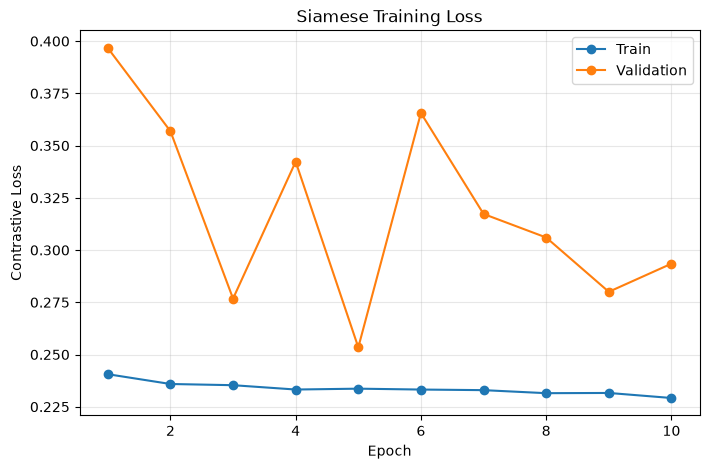

In [21]:
plt.figure(
    figsize=(8, 5)
)


plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train"
)


plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Contrastive Loss"
)

plt.title(
    "Siamese Training Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

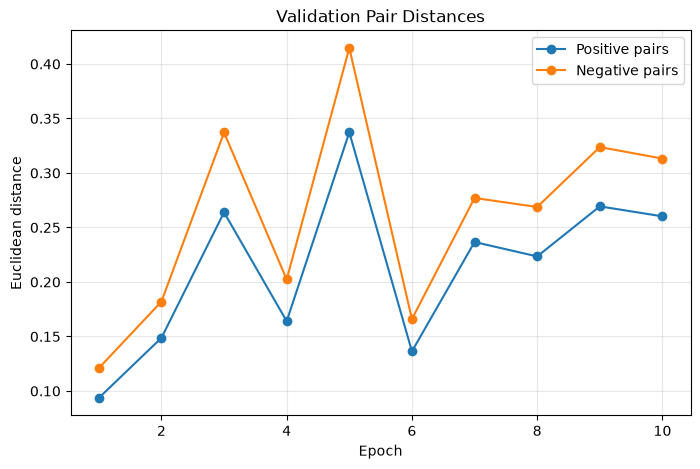

In [22]:
plt.figure(
    figsize=(8, 5)
)


plt.plot(

    history_df["epoch"],

    history_df[
        "val_positive_distance"
    ],

    marker="o",

    label=
        "Positive pairs"
)


plt.plot(

    history_df["epoch"],

    history_df[
        "val_negative_distance"
    ],

    marker="o",

    label=
        "Negative pairs"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Euclidean distance"
)

plt.title(
    "Validation Pair Distances"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

In [23]:
checkpoint = torch.load(

    CHECKPOINT_PATH,

    map_location=
        DEVICE,

    weights_only=False
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


model.eval()


print(
    "Best epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation loss:",
    checkpoint["val_loss"]
)

Best epoch: 5
Best validation loss: 0.25343547093868257


In [24]:
val_results = run_epoch(

    model=
        model,

    loader=
        val_loader,

    criterion=
        criterion,

    device=
        DEVICE
)


val_distances = (
    val_results[
        "distances"
    ]
)


val_targets = (
    val_results[
        "targets"
    ]
)


print(
    "Validation loss:",
    val_results["loss"]
)

print(
    "Mean positive distance:",
    val_results[
        "mean_positive_distance"
    ]
)

print(
    "Mean negative distance:",
    val_results[
        "mean_negative_distance"
    ]
)

Validation loss: 0.25343547093868257
Mean positive distance: 0.33732012
Mean negative distance: 0.41467294


In [25]:
def find_best_threshold(
    targets,
    distances,
    n_thresholds=500
):

    thresholds = np.linspace(

        distances.min(),

        distances.max(),

        n_thresholds
    )


    best_threshold = None

    best_f1 = -1


    for threshold in thresholds:

        predictions = (
            distances
            <=
            threshold
        ).astype(int)


        score = f1_score(

            targets,

            predictions,

            average="macro"
        )


        if score > best_f1:

            best_f1 = (
                score
            )

            best_threshold = (
                threshold
            )


    return (
        best_threshold,
        best_f1
    )


best_threshold, val_macro_f1 = (
    find_best_threshold(

        val_targets,

        val_distances
    )
)


print(
    "Best threshold:",
    best_threshold
)

print(
    "Validation Macro F1:",
    val_macro_f1
)

Best threshold: 0.37442493
Validation Macro F1: 0.5983942008122598


In [26]:
def compute_pair_metrics(
    targets,
    distances,
    threshold
):

    predictions = (
        distances
        <=
        threshold
    ).astype(int)


    similarity_scores = (
        -distances
    )


    return {

        "accuracy":
            accuracy_score(
                targets,
                predictions
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                targets,
                predictions
            ),

        "macro_f1":
            f1_score(
                targets,
                predictions,
                average="macro"
            ),

        "precision":
            precision_score(
                targets,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                targets,
                predictions,
                zero_division=0
            ),

        "roc_auc":
            roc_auc_score(
                targets,
                similarity_scores
            )
    }


val_metrics = (
    compute_pair_metrics(

        val_targets,

        val_distances,

        best_threshold
    )
)


pd.DataFrame(
    [val_metrics]
)

,accuracy,balanced_accuracy,macro_f1,precision,recall,roc_auc
0,0.5984,0.598432,0.598394,0.594824,0.605105,0.635102


In [27]:
test_results = run_epoch(

    model=
        model,

    loader=
        test_loader,

    criterion=
        criterion,

    device=
        DEVICE
)


test_distances = (
    test_results[
        "distances"
    ]
)


test_targets = (
    test_results[
        "targets"
    ]
)


test_metrics = (
    compute_pair_metrics(

        test_targets,

        test_distances,

        best_threshold
    )
)


print(
    "Test loss:",
    test_results["loss"]
)

print(
    "Positive distance:",
    test_results[
        "mean_positive_distance"
    ]
)

print(
    "Negative distance:",
    test_results[
        "mean_negative_distance"
    ]
)


display(
    pd.DataFrame(
        [test_metrics]
    )
)

Test loss: 0.2558336181640625
Positive distance: 0.33387482
Negative distance: 0.40964082


,accuracy,balanced_accuracy,macro_f1,precision,recall,roc_auc
0,0.5921,0.59214,0.592044,0.58827,0.605617,0.631155


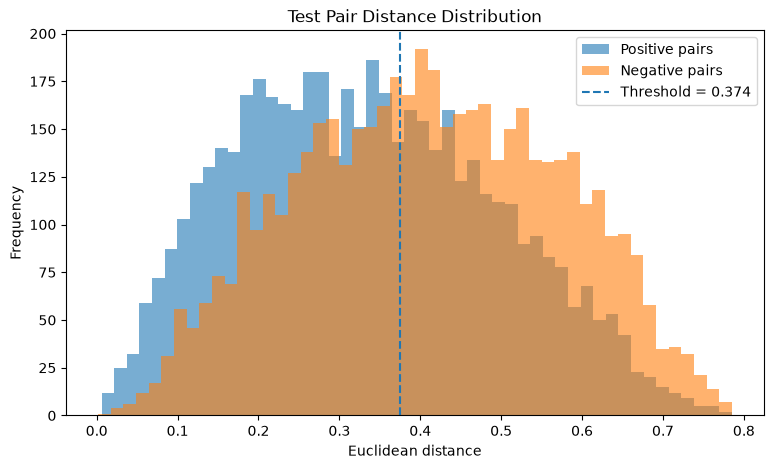

In [28]:
positive_test_distances = (
    test_distances[
        test_targets == 1
    ]
)


negative_test_distances = (
    test_distances[
        test_targets == 0
    ]
)


plt.figure(
    figsize=(9, 5)
)


plt.hist(

    positive_test_distances,

    bins=50,

    alpha=0.6,

    label=
        "Positive pairs"
)


plt.hist(

    negative_test_distances,

    bins=50,

    alpha=0.6,

    label=
        "Negative pairs"
)


plt.axvline(

    best_threshold,

    linestyle="--",

    label=
        f"Threshold = "
        f"{best_threshold:.3f}"
)


plt.xlabel(
    "Euclidean distance"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Test Pair Distance Distribution"
)

plt.legend()

plt.show()

[[2902 2113]
 [1966 3019]]


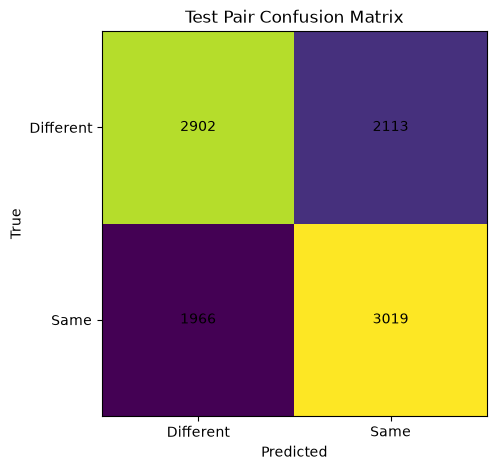

In [29]:
test_predictions = (

    test_distances
    <=
    best_threshold

).astype(int)


cm = confusion_matrix(

    test_targets,

    test_predictions,

    labels=[
        0,
        1
    ]
)


print(
    cm
)


fig, ax = plt.subplots(
    figsize=(5, 5)
)


image = ax.imshow(
    cm
)


ax.set_xticks(
    [0, 1]
)

ax.set_yticks(
    [0, 1]
)


ax.set_xticklabels(
    [
        "Different",
        "Same"
    ]
)


ax.set_yticklabels(
    [
        "Different",
        "Same"
    ]
)


ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "True"
)


ax.set_title(
    "Test Pair Confusion Matrix"
)


for i in range(2):

    for j in range(2):

        ax.text(

            j,
            i,

            str(
                cm[i, j]
            ),

            ha="center",

            va="center"
        )


plt.show()

In [30]:
RESULTS_PATH = (
    ARTIFACTS_DIR
    / "pair_metrics.json"
)


results = {

    "best_epoch":
        int(
            checkpoint["epoch"]
        ),

    "best_val_loss":
        float(
            checkpoint["val_loss"]
        ),

    "threshold":
        float(
            best_threshold
        ),

    "embedding_dim":
        EMBEDDING_DIM,

    "margin":
        MARGIN,

    "k":
        DEFAULT_K,

    "validation":
        {
            key:
                float(value)

            for key, value
            in val_metrics.items()
        },

    "test":
        {
            key:
                float(value)

            for key, value
            in test_metrics.items()
        }
}


with open(
    RESULTS_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        results,
        f,
        indent=4
    )


print(
    "Risultati salvati:",
    RESULTS_PATH
)

Risultati salvati: D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\siamese_baseline\pair_metrics.json


# Conclusioni

È stata implementata una prima CNN Siamese per l'analisi delle FCGR
derivate dalle sequenze eccDNA.

I due input vengono elaborati dallo stesso CNN encoder, che genera
embedding normalizzati di 128 dimensioni.

Il modello viene addestrato mediante Contrastive Loss e distanza euclidea:

- le coppie positive vengono spinte verso distanze ridotte;
- le coppie negative vengono spinte oltre un margine prefissato.

La soglia utilizzata per distinguere pair positivi e negativi viene
determinata esclusivamente sul validation set.

Il test set viene utilizzato solamente dopo la selezione del modello e
della soglia.

Questa configurazione rappresenta la baseline di metric learning del
progetto.

I passi successivi comprenderanno:

- analisi degli embedding;
- classificazione multiclass mediante prototipi di classe;
- confronto con cosine similarity;
- confronto con altre loss metric-learning;
- ablation study sulla dimensione dell'embedding e sul valore di k.